# Week 04 Lab Work

**Dataset:** Adult / Census Income (UCI Machine Learning Repository) - `adult.data`

1. Take a dataset from the internet (used for all future labs).
2. Calculate the dissimilarity or similarity of a data matrix.
3. Calculate the dissimilarity of a mix type of attributes.

The Adult dataset is used because it contains all four attribute types needed for Task 3:
numeric, nominal, binary and ordinal.

## 1. Load the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols = ["age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]

df = pd.read_csv("adult dataset/adult.data", header=None, names=cols,
                 skipinitialspace=True, na_values="?")
df = df.dropna().reset_index(drop=True)
df.shape

(30162, 15)

In [2]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Attribute types

| Type | Attributes |
|---|---|
| Numeric (ratio/interval) | `age`, `capital-gain`, `capital-loss`, `hours-per-week` |
| Nominal | `workclass`, `occupation`, `marital-status`, `race`, `native-country` |
| Binary (asymmetric) | `sex` (Male=1), `income` (>50K=1) |
| Ordinal | `education` ranked by `education-num` (1 = Preschool ... 16 = Doctorate) |

### Take a small sample

A distance matrix of the full 30,162 rows would be 30,162 x 30,162.
A sample of 10 objects is used so every matrix can be printed.

In [3]:
S = df.sample(10, random_state=42).reset_index(drop=True)
S.index = [f"o{i+1}" for i in range(len(S))]
S[["age", "hours-per-week", "capital-gain", "education", "education-num",
   "workclass", "occupation", "race", "sex", "income"]]

,age,hours-per-week,capital-gain,education,education-num,workclass,occupation,race,sex,income
o1,28,55,0,Prof-school,15,Private,Prof-specialty,White,Male,>50K
o2,41,40,0,HS-grad,9,Private,Craft-repair,Asian-Pac-Islander,Male,<=50K
o3,53,50,0,HS-grad,9,Private,Other-service,White,Male,>50K
o4,31,45,0,HS-grad,9,Private,Craft-repair,White,Male,<=50K
o5,34,40,0,Bachelors,13,Local-gov,Prof-specialty,White,Female,<=50K
o6,34,40,0,HS-grad,9,Private,Transport-moving,White,Male,>50K
o7,34,40,0,HS-grad,9,Private,Adm-clerical,White,Male,<=50K
o8,52,40,0,Some-college,10,Private,Exec-managerial,White,Female,<=50K
o9,49,15,0,HS-grad,9,Private,Sales,White,Male,<=50K
o10,36,50,0,Some-college,10,Private,Prof-specialty,White,Male,<=50K


## 2. Dissimilarity / similarity of a data matrix

### 2.1 Numeric attributes

Values are min-max normalised to [0, 1] first, so that `capital-gain` (range ~100,000)
does not drown out `age` (range ~70).

$$z = \frac{x - min}{max - min}$$

In [4]:
numeric = ["age", "capital-gain", "capital-loss", "hours-per-week"]

lo, hi = df[numeric].min(), df[numeric].max()
rng = (hi - lo).replace(0, 1)
Z = (S[numeric] - lo) / rng
Z.round(3)

,age,capital-gain,capital-loss,hours-per-week
o1,0.151,0.0,0.0,0.551
o2,0.329,0.0,0.0,0.398
o3,0.493,0.0,0.0,0.500
o4,0.192,0.0,0.0,0.449
o5,0.233,0.0,0.0,0.398
o6,0.233,0.0,0.0,0.398
o7,0.233,0.0,0.0,0.398
o8,0.479,0.0,0.0,0.398
o9,0.438,0.0,0.0,0.143
o10,0.260,0.0,0.0,0.500


Minkowski distance of order $p$:

$$d(i,j) = \left(\sum_{f=1}^{n} |x_{if} - x_{jf}|^{p}\right)^{1/p}$$

$p = 1$ gives Manhattan distance, $p = 2$ gives Euclidean distance.

In [5]:
def minkowski_matrix(X, p):
    diff = np.abs(X.values[:, None, :] - X.values[None, :, :]) ** p
    return pd.DataFrame(diff.sum(axis=2) ** (1 / p), index=X.index, columns=X.index)

manhattan = minkowski_matrix(Z, 1)
euclidean = minkowski_matrix(Z, 2)

print("Manhattan (p = 1)")
display(manhattan.round(3))
print("Euclidean (p = 2)")
display(euclidean.round(3))

Manhattan (p = 1)


,o1,o2,o3,o4,o5,o6,o7,o8,o9,o10
o1,0.000,0.331,0.393,0.143,0.235,0.235,0.235,0.482,0.696,0.161
o2,0.331,0.000,0.266,0.188,0.096,0.096,0.096,0.151,0.365,0.171
o3,0.393,0.266,0.000,0.352,0.362,0.362,0.362,0.116,0.412,0.233
o4,0.143,0.188,0.352,0.000,0.092,0.092,0.092,0.339,0.553,0.120
o5,0.235,0.096,0.362,0.092,0.000,0.000,0.000,0.247,0.461,0.129
o6,0.235,0.096,0.362,0.092,0.000,0.000,0.000,0.247,0.461,0.129
o7,0.235,0.096,0.362,0.092,0.000,0.000,0.000,0.247,0.461,0.129
o8,0.482,0.151,0.116,0.339,0.247,0.247,0.247,0.000,0.296,0.321
o9,0.696,0.365,0.412,0.553,0.461,0.461,0.461,0.296,0.000,0.535
o10,0.161,0.171,0.233,0.120,0.129,0.129,0.129,0.321,0.535,0.000


Euclidean (p = 2)


,o1,o2,o3,o4,o5,o6,o7,o8,o9,o10
o1,0.000,0.235,0.346,0.110,0.174,0.174,0.174,0.363,0.499,0.121
o2,0.235,0.000,0.193,0.146,0.096,0.096,0.096,0.151,0.278,0.123
o3,0.346,0.193,0.000,0.306,0.280,0.280,0.280,0.103,0.361,0.233
o4,0.110,0.146,0.306,0.000,0.066,0.066,0.066,0.292,0.393,0.085
o5,0.174,0.096,0.280,0.066,0.000,0.000,0.000,0.247,0.328,0.106
o6,0.174,0.096,0.280,0.066,0.000,0.000,0.000,0.247,0.328,0.106
o7,0.174,0.096,0.280,0.066,0.000,0.000,0.000,0.247,0.328,0.106
o8,0.363,0.151,0.103,0.292,0.247,0.247,0.247,0.000,0.258,0.242
o9,0.499,0.278,0.361,0.393,0.328,0.328,0.328,0.258,0.000,0.399
o10,0.121,0.123,0.233,0.085,0.106,0.106,0.106,0.242,0.399,0.000


### 2.2 Nominal attributes

Simple matching: count how many attributes disagree.

$$d(i,j) = \frac{p - m}{p}$$

where $p$ is the number of attributes and $m$ the number of matches.

In [6]:
nominal = ["workclass", "occupation", "marital-status", "race", "native-country"]

V = S[nominal].to_numpy(dtype=object)
p = len(nominal)
mismatch = (V[:, None, :] != V[None, :, :]).sum(axis=2)
nominal_d = pd.DataFrame(mismatch / p, index=S.index, columns=S.index)
nominal_d.round(3)

,o1,o2,o3,o4,o5,o6,o7,o8,o9,o10
o1,0.0,0.8,0.6,0.4,0.4,0.4,0.4,0.4,0.6,0.2
o2,0.8,0.0,0.6,0.4,1.0,0.6,0.8,0.8,0.6,0.8
o3,0.6,0.6,0.0,0.4,0.8,0.4,0.6,0.6,0.4,0.6
o4,0.4,0.4,0.4,0.0,0.6,0.2,0.4,0.4,0.4,0.4
o5,0.4,1.0,0.8,0.6,0.0,0.6,0.6,0.6,0.8,0.4
o6,0.4,0.6,0.4,0.2,0.6,0.0,0.4,0.4,0.4,0.4
o7,0.4,0.8,0.6,0.4,0.6,0.4,0.0,0.4,0.6,0.4
o8,0.4,0.8,0.6,0.4,0.6,0.4,0.4,0.0,0.6,0.2
o9,0.6,0.6,0.4,0.4,0.8,0.4,0.6,0.6,0.0,0.6
o10,0.2,0.8,0.6,0.4,0.4,0.4,0.4,0.2,0.6,0.0


### 2.3 Binary attributes (asymmetric)

`sex = Male` and `income > 50K` are treated as the rare/positive outcome (1).
For asymmetric binary attributes the 0-0 match carries no information, so the
Jaccard coefficient is used:

$$d(i,j) = \frac{b + c}{a + b + c}$$

where $a$ = attributes that are 1 in both objects, $b$ and $c$ = the mismatches.

In [7]:
B = pd.DataFrame({"sex_male": (S["sex"] == "Male").astype(int),
                  "income_gt50k": (S["income"] == ">50K").astype(int)},
                 index=S.index)
display(B)

X = B.values
a = ((X[:, None, :] == 1) & (X[None, :, :] == 1)).sum(axis=2)
b_c = (X[:, None, :] != X[None, :, :]).sum(axis=2)
denom = np.where(a + b_c == 0, 1, a + b_c)
binary_d = pd.DataFrame(b_c / denom, index=S.index, columns=S.index)
binary_d.round(3)

,sex_male,income_gt50k
o1,1,1
o2,1,0
o3,1,1
o4,1,0
o5,0,0
o6,1,1
o7,1,0
o8,0,0
o9,1,0
o10,1,0


,o1,o2,o3,o4,o5,o6,o7,o8,o9,o10
o1,0.0,0.5,0.0,0.5,1.0,0.0,0.5,1.0,0.5,0.5
o2,0.5,0.0,0.5,0.0,1.0,0.5,0.0,1.0,0.0,0.0
o3,0.0,0.5,0.0,0.5,1.0,0.0,0.5,1.0,0.5,0.5
o4,0.5,0.0,0.5,0.0,1.0,0.5,0.0,1.0,0.0,0.0
o5,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
o6,0.0,0.5,0.0,0.5,1.0,0.0,0.5,1.0,0.5,0.5
o7,0.5,0.0,0.5,0.0,1.0,0.5,0.0,1.0,0.0,0.0
o8,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
o9,0.5,0.0,0.5,0.0,1.0,0.5,0.0,1.0,0.0,0.0
o10,0.5,0.0,0.5,0.0,1.0,0.5,0.0,1.0,0.0,0.0


### 2.4 Ordinal attribute

`education` has a natural order. Its rank $r \in \{1 \dots M\}$ is already stored in
`education-num` ($M = 16$). The rank is mapped to [0, 1] and then treated as numeric:

$$z = \frac{r - 1}{M - 1}, \qquad d(i,j) = |z_i - z_j|$$

In [8]:
M = df["education-num"].max()
z_edu = (S["education-num"] - 1) / (M - 1)
display(pd.DataFrame({"education": S["education"], "rank": S["education-num"],
                      "z": z_edu.round(3)}))

ordinal_d = pd.DataFrame(np.abs(z_edu.values[:, None] - z_edu.values[None, :]),
                         index=S.index, columns=S.index)
ordinal_d.round(3)

,education,rank,z
o1,Prof-school,15,0.933
o2,HS-grad,9,0.533
o3,HS-grad,9,0.533
o4,HS-grad,9,0.533
o5,Bachelors,13,0.800
o6,HS-grad,9,0.533
o7,HS-grad,9,0.533
o8,Some-college,10,0.600
o9,HS-grad,9,0.533
o10,Some-college,10,0.600


,o1,o2,o3,o4,o5,o6,o7,o8,o9,o10
o1,0.000,0.400,0.400,0.400,0.133,0.400,0.400,0.333,0.400,0.333
o2,0.400,0.000,0.000,0.000,0.267,0.000,0.000,0.067,0.000,0.067
o3,0.400,0.000,0.000,0.000,0.267,0.000,0.000,0.067,0.000,0.067
o4,0.400,0.000,0.000,0.000,0.267,0.000,0.000,0.067,0.000,0.067
o5,0.133,0.267,0.267,0.267,0.000,0.267,0.267,0.200,0.267,0.200
o6,0.400,0.000,0.000,0.000,0.267,0.000,0.000,0.067,0.000,0.067
o7,0.400,0.000,0.000,0.000,0.267,0.000,0.000,0.067,0.000,0.067
o8,0.333,0.067,0.067,0.067,0.200,0.067,0.067,0.000,0.067,0.000
o9,0.400,0.000,0.000,0.000,0.267,0.000,0.000,0.067,0.000,0.067
o10,0.333,0.067,0.067,0.067,0.200,0.067,0.067,0.000,0.067,0.000


### 2.5 Similarity

Cosine similarity on the normalised numeric matrix. It measures the angle between two
object vectors, so it ranges from 0 (unrelated) to 1 (identical direction).

$$sim(i,j) = \frac{x_i \cdot x_j}{\|x_i\| \, \|x_j\|}$$

In [9]:
norms = np.linalg.norm(Z.values, axis=1)
norms = np.where(norms == 0, 1, norms)
cosine_sim = pd.DataFrame((Z.values @ Z.values.T) / np.outer(norms, norms),
                          index=S.index, columns=S.index)
cosine_sim.round(3)

,o1,o2,o3,o4,o5,o6,o7,o8,o9,o10
o1,1.000,0.912,0.872,0.991,0.966,0.966,0.966,0.819,0.550,0.977
o2,0.912,1.000,0.996,0.959,0.987,0.987,0.987,0.982,0.844,0.978
o3,0.872,0.996,1.000,0.931,0.969,0.969,0.969,0.995,0.888,0.956
o4,0.991,0.959,0.931,1.000,0.992,0.992,0.992,0.890,0.658,0.997
o5,0.966,0.987,0.969,0.992,1.000,1.000,1.000,0.940,0.748,0.999
o6,0.966,0.987,0.969,0.992,1.000,1.000,1.000,0.940,0.748,0.999
o7,0.966,0.987,0.969,0.992,1.000,1.000,1.000,0.940,0.748,0.999
o8,0.819,0.982,0.995,0.890,0.940,0.940,0.940,1.000,0.929,0.922
o9,0.550,0.844,0.888,0.658,0.748,0.748,0.748,0.929,1.000,0.714
o10,0.977,0.978,0.956,0.997,0.999,0.999,0.999,0.922,0.714,1.000


## 3. Dissimilarity of mixed type attributes

All four types are combined into one matrix with the weighted formula:

$$d(i,j) = \frac{\sum_{f=1}^{n} \delta_{ij}^{(f)} \, d_{ij}^{(f)}}{\sum_{f=1}^{n} \delta_{ij}^{(f)}}$$

Per attribute $f$:

| Type | $d_{ij}^{(f)}$ | $\delta_{ij}^{(f)}$ |
|---|---|---|
| Numeric | $\dfrac{\lvert x_{if} - x_{jf}\rvert}{max_f - min_f}$ | 1 |
| Nominal | 0 if equal, else 1 | 1 |
| Ordinal | $\lvert z_{if} - z_{jf}\rvert$ after rank normalisation | 1 |
| Asymmetric binary | 0 if equal, else 1 | 0 if both are 0, else 1 |

Every $d_{ij}^{(f)}$ is already in [0, 1], so the result is also in [0, 1].

In [10]:
def mixed_dissimilarity(S):
    n = len(S)
    contrib = np.zeros((n, n))
    weight = np.zeros((n, n))

    for f in numeric:
        x = S[f].values.astype(float)
        r = hi[f] - lo[f] or 1
        contrib += np.abs(x[:, None] - x[None, :]) / r
        weight += 1

    for f in nominal:
        x = S[f].to_numpy(dtype=object)
        contrib += (x[:, None] != x[None, :]).astype(float)
        weight += 1

    x = z_edu.values
    contrib += np.abs(x[:, None] - x[None, :])
    weight += 1

    for f in B.columns:
        x = B[f].values
        delta = ~((x[:, None] == 0) & (x[None, :] == 0))
        contrib += (x[:, None] != x[None, :]) * delta
        weight += delta

    return pd.DataFrame(contrib / weight, index=S.index, columns=S.index)

mixed_d = mixed_dissimilarity(S)
mixed_d.round(3)

,o1,o2,o3,o4,o5,o6,o7,o8,o9,o10
o1,0.000,0.478,0.316,0.295,0.364,0.220,0.303,0.401,0.425,0.208
o2,0.478,0.000,0.356,0.199,0.578,0.341,0.372,0.474,0.306,0.385
o3,0.316,0.356,0.000,0.279,0.552,0.197,0.364,0.432,0.284,0.358
o4,0.295,0.199,0.279,0.000,0.396,0.174,0.190,0.310,0.232,0.199
o5,0.364,0.578,0.552,0.396,0.000,0.439,0.388,0.345,0.521,0.303
o6,0.220,0.341,0.197,0.174,0.439,0.000,0.250,0.359,0.288,0.266
o7,0.303,0.372,0.364,0.190,0.388,0.250,0.000,0.301,0.315,0.200
o8,0.401,0.474,0.432,0.310,0.345,0.359,0.301,0.000,0.397,0.211
o9,0.425,0.306,0.284,0.232,0.521,0.288,0.315,0.397,0.000,0.327
o10,0.208,0.385,0.358,0.199,0.303,0.266,0.200,0.211,0.327,0.000


### Heatmap of the mixed-type dissimilarity matrix

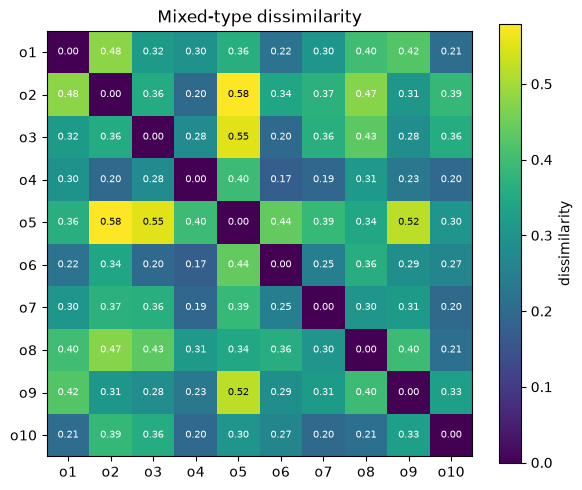

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mixed_d.values, cmap="viridis")
ax.set_xticks(range(len(S)), S.index)
ax.set_yticks(range(len(S)), S.index)
ax.set_title("Mixed-type dissimilarity")
for i in range(len(S)):
    for j in range(len(S)):
        ax.text(j, i, f"{mixed_d.values[i, j]:.2f}", ha="center", va="center",
                color="white" if mixed_d.values[i, j] < 0.5 else "black", fontsize=7)
fig.colorbar(im, label="dissimilarity")
plt.tight_layout()
plt.show()

### Most similar and most different pair

In [12]:
d = mixed_d.values.copy()
np.fill_diagonal(d, np.nan)
i, j = np.unravel_index(np.nanargmin(d), d.shape)
k, l = np.unravel_index(np.nanargmax(d), d.shape)

print(f"most similar : {S.index[i]} and {S.index[j]}  d = {d[i, j]:.3f}")
print(f"most different: {S.index[k]} and {S.index[l]}  d = {d[k, l]:.3f}")

cmp = ["age", "hours-per-week", "education", "workclass", "occupation",
       "marital-status", "race", "sex", "income"]
display(S.loc[[S.index[i], S.index[j]], cmp].T.rename(columns={S.index[i]: "A", S.index[j]: "B"}))
display(S.loc[[S.index[k], S.index[l]], cmp].T.rename(columns={S.index[k]: "A", S.index[l]: "B"}))

most similar : o4 and o6  d = 0.174
most different: o2 and o5  d = 0.578


,A,B
age,31,34
hours-per-week,45,40
education,HS-grad,HS-grad
workclass,Private,Private
occupation,Craft-repair,Transport-moving
marital-status,Married-civ-spouse,Married-civ-spouse
race,White,White
sex,Male,Male
income,<=50K,>50K


,A,B
age,41,34
hours-per-week,40,40
education,HS-grad,Bachelors
workclass,Private,Local-gov
occupation,Craft-repair,Prof-specialty
marital-status,Married-civ-spouse,Married-spouse-absent
race,Asian-Pac-Islander,White
sex,Male,Female
income,<=50K,<=50K


## Summary

- The dataset for all future labs is **Adult / Census Income (UCI)**, 30,162 complete records.
- Task 2: dissimilarity matrices were built for numeric (Manhattan, Euclidean),
  nominal (simple matching), asymmetric binary (Jaccard) and ordinal (rank normalisation)
  attributes, plus a cosine similarity matrix.
- Task 3: all four types were merged into a single dissimilarity matrix with the weighted
  formula, giving values in [0, 1].